# User Engagement & Retention Analysis for Mobile App

### Hanish Kumar Kukkala  
### Data Science Case Study  

This project analyzes user behavior to understand engagement patterns, identify drop-offs, and build a predictive approach to improve retention and product experience.

## Problem Statement

The goal of this project is to analyze user activity data from a mobile application to uncover actionable insights that can improve user engagement and retention.

Key objectives:
- Understand user behavior patterns  
- Analyze engagement distribution  
- Identify drop-offs in user journey  
- Detect early signs of disengagement  
- Build a predictive model for at-risk users  

### Step 1: Load and Inspect Data

In this step, I load the dataset and inspect its structure to understand the available features.

In [29]:
import pandas as pd

df = pd.read_csv("data_science_seasonal.csv")
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

df.head()

,event_dt,event_timestamp,event_name,user_id,platform_type,country,app_version
0,2024-01-01,2024-01-01 00:00:03,highlight_verse,6207974,Android,US,9.6.1
1,2024-01-01,2024-01-01 00:00:14,plan_day_read,3237058,iOS,FR,9.5.3
2,2024-01-01,2024-01-01 00:00:17,video_stopped,7667458,Android,US,9.5.0
3,2024-01-01,2024-01-01 00:00:48,highlight_verse,6068760,Android,US,9.3.0
4,2024-01-01,2024-01-01 00:00:48,app_open,8312114,Android,US,9.6.0


The dataset contains time-stamped user interaction events from a mobile application.

Each record represents a specific user action (event_name) along with contextual information such as user_id, platform type, country, and app version.

The presence of detailed attributes like timestamp and user identifiers enables tracking user behavior over time, making it suitable for analyzing engagement patterns, user journeys, and retention behavior.

### Step 2: Event Distribution Analysis

In this step, I analyze the frequency of different user actions to understand what users do most frequently.

In [30]:
df['event_name'].value_counts()

event_name
app_open           45662
plan_day_read      33619
highlight_verse    22794
video_started      14817
video_stopped      13739
start_plan         10615
verse_shared        6071
create_account      4529
Name: count, dtype: int64

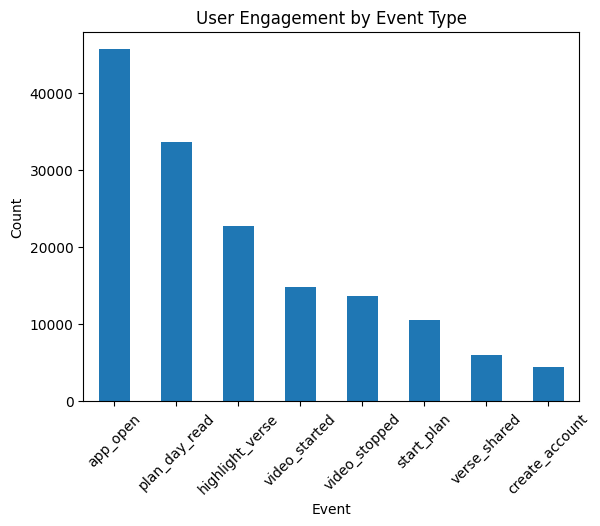

In [31]:
df['event_name'].value_counts().plot(kind='bar')
plt.title("User Engagement by Event Type")
plt.xlabel("Event")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The visualization clearly shows that app_open is the most frequent user action, indicating consistent user entry into the application.

Reading-related actions such as plan_day_read and highlight_verse are the next most common, confirming that users primarily engage with the app through content consumption.

Video-related interactions (video_started and video_stopped) are significantly lower compared to reading actions, suggesting that video content is not a primary engagement driver.

Additionally, actions like verse_shared and create_account have the lowest counts, indicating that social engagement and onboarding events contribute less to overall activity.

Overall, the chart highlights that user engagement is heavily concentrated around reading behavior rather than multimedia or social features.

### Step 3: User Activity Analysis

In this step, I analyze how active users are by calculating the number of events performed by each user.

In [32]:
user_activity = df.groupby('user_id').size()
user_activity.describe()

count    1000.000000
mean      151.846000
std        30.951547
min       115.000000
25%       142.000000
50%       150.000000
75%       158.000000
max       676.000000
dtype: float64

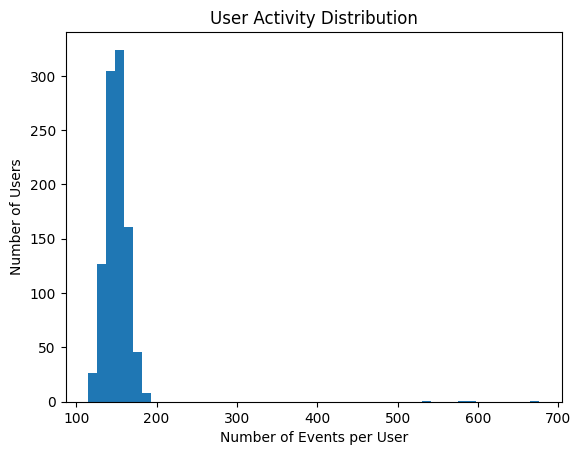

In [33]:
import matplotlib.pyplot as plt

user_activity.plot(kind='hist', bins=50)
plt.title("User Activity Distribution")
plt.xlabel("Number of Events per User")
plt.ylabel("Number of Users")
plt.show()

User activity shows a relatively high and consistent level of engagement across the user base.

The average number of events per user is around 151, with most users falling within a narrow range (115 to 158 events), as indicated by the 25th and 75th percentiles.

However, there are a few outliers, with some users reaching up to 676 events, indicating the presence of highly engaged users.

Overall, this suggests that while most users are consistently active, a small subset of users exhibits significantly higher engagement levels.

### Step 4: User Journey Analysis (Funnel)

In this step, I analyze the sequence of user actions to understand how users move through the application.

In [34]:
df = df.sort_values(['user_id', 'event_timestamp'])

df['next_event'] = df.groupby('user_id')['event_name'].shift(-1)

In [35]:
app_to_video = len(df[(df['event_name']=='app_open') & (df['next_event']=='video_started')])
video_to_complete = len(df[(df['event_name']=='video_started') & (df['next_event']=='video_stopped')])
total_app_open = len(df[df['event_name']=='app_open'])

print("App → Video:", app_to_video / total_app_open)
print("Video → Complete:", video_to_complete / app_to_video)

App → Video: 0.09734571416057115
Video → Complete: 0.2992125984251969


The funnel analysis shows that only about 9.7% of users transition from app_open to video_started, indicating that a large majority of users do not engage with video content after entering the app.

Among users who do start a video, only around 29.9% complete it, suggesting additional drop-off even after initial engagement.

This highlights two key issues:
1. Low discovery or visibility of video content (major drop at entry stage)
2. Limited retention within video consumption (drop during playback)

Overall, user engagement with video content is relatively weak, pointing to opportunities for improving content discovery and user experience. This indicates that the primary bottleneck is content discovery rather than content quality.

### Step 5: User Segmentation

In this step, I segment users based on their activity levels.

In [36]:
user_features = df.groupby('user_id').agg({
    'event_name': 'count',
    'event_timestamp': ['min','max']
}).reset_index()

user_features.columns = ['user_id','event_count','first_event','last_event']

user_features['active_days'] = (
    user_features['last_event'] - user_features['first_event']
).dt.days

In [37]:
q1 = user_features['event_count'].quantile(0.33)
q2 = user_features['event_count'].quantile(0.66)

def segment(x):
    if x >= q2:
        return "High Value"
    elif x >= q1:
        return "Moderate"
    else:
        return "Low Engagement"

user_features['segment'] = user_features['event_count'].apply(segment)

user_features['segment'].value_counts()

segment
High Value        355
Moderate          330
Low Engagement    315
Name: count, dtype: int64

In [22]:
user_features['engagement_score'] = (
    user_features['event_count'] / (user_features['active_days'] + 1)
)

user_features[['user_id','engagement_score']].head()

,user_id,engagement_score
0,1006810,0.469945
1,1009594,0.480874
2,1019311,0.387978
3,1028374,0.398907
4,1036161,0.409836



User segmentation shows a balanced distribution across engagement levels, with 355 high-value users, 330 moderate users, and 315 low-engagement users.

This indicates that engagement is fairly evenly spread across the user base rather than concentrated in a small group.

The introduction of the engagement score provides a more refined view by normalizing activity over time, helping distinguish between users with short bursts of activity and those with consistent engagement.

High-value users represent a critical segment for retention, while low-engagement users highlight opportunities to improve onboarding and drive deeper engagement.

Overall, this segmentation combined with engagement scoring provides a strong foundation for targeted user strategies and personalized product improvements.

### Step 6: Retention Analysis

In this step, I analyze how recently users have been active.

In [38]:
last_activity = df.groupby('user_id')['event_timestamp'].max().reset_index()

reference_date = df['event_timestamp'].max()

last_activity['days_inactive'] = (
    reference_date - last_activity['event_timestamp']
).dt.days

last_activity['days_inactive'].describe()

count    1000.000000
mean        0.003000
std         0.094868
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: days_inactive, dtype: float64

The retention analysis shows that user inactivity is extremely low across the dataset.

The average inactivity is close to zero (0.003 days), and most users have 0 days of inactivity, as indicated by the median and quartiles.

The maximum inactivity observed is only 3 days, which suggests that nearly all users remain recently active.

This indicates that the dataset does not capture long-term disengagement or churn behavior, making it difficult to build a true churn prediction model.

However, short-term inactivity can still be used as an early signal to identify users who may be at risk of disengagement.

### Step 7: Identify At-Risk Users

In this step, I identify users showing early signs of disengagement.

In [39]:
at_risk_users = last_activity[last_activity['days_inactive'] > 1]

len(at_risk_users)

1

The analysis shows that only 1 user falls into the at-risk category based on the defined inactivity threshold.

This represents a very small fraction of the total user base, indicating that almost all users remain actively engaged within the observed time window.

This further confirms that the dataset does not capture significant disengagement or churn behavior.

However, even this small signal demonstrates how inactivity can be used to identify users who may require targeted re-engagement strategies.

### Class Distribution Analysis

In this step, I analyze the distribution of the target variable before building the model.

In [40]:
data['at_risk'].value_counts()

at_risk
0    999
1      1
Name: count, dtype: int64

The dataset shows extreme class imbalance, with 999 users labeled as active and only 1 user labeled as at-risk.

This imbalance makes it difficult for the model to learn meaningful patterns for predicting disengagement.

As a result, the model is likely to be biased toward predicting users as active.

This highlights a data limitation rather than a modeling issue.

To address this, techniques such as resampling, anomaly detection, or collecting longer-term data with more inactive users would be required.



### Step 8: Predictive Modeling for At-Risk Users

In this step, I build a predictive modeling approach to identify users who are at risk of disengagement.

Given the limited churn signal in the dataset, I approach this problem using:
1. A baseline model for benchmarking
2. A class-weighted model to handle imbalance
3. An anomaly detection approach as an alternative strategy

Step 8.1 — Prepare Data

In [46]:
# Merge features and inactivity
data = user_features.merge(
    last_activity[['user_id','days_inactive']],
    on='user_id'
)

# Define target
data['at_risk'] = (data['days_inactive'] > 1).astype(int)

# Features
X = data[['event_count','active_days']]
y = data['at_risk']

data.head()

,user_id,event_count,first_event,last_event,active_days,segment,days_inactive,at_risk
0,1006810,172,2024-01-01 12:03:05,2024-12-31 21:19:47,365,High Value,0,0
1,1009594,176,2024-01-01 01:27:20,2024-12-31 20:59:18,365,High Value,0,0
2,1019311,142,2024-01-01 01:16:32,2024-12-31 21:39:42,365,Low Engagement,0,0
3,1028374,146,2024-01-01 00:49:08,2024-12-31 16:39:08,365,Moderate,0,0
4,1036161,150,2024-01-01 00:02:08,2024-12-31 13:25:54,365,Moderate,0,0


The target distribution shows extreme class imbalance, with almost all users labeled as active and very few labeled as at-risk.

This confirms that churn signals are minimal in the dataset and will impact model performance.

Step 8.2 — Baseline Model

In [47]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression()
baseline_model.fit(X, y)

print("Baseline model trained")

Baseline model trained


A baseline logistic regression model was first implemented to establish a simple benchmark before applying more complex models.

Step 8.3 — Class-Weighted RandomForest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Class weighting is applied to address extreme class imbalance, ensuring that the minority class (at-risk users) is given higher importance during training.

Step 8.4 — Model Evaluation

In [64]:
from sklearn.metrics import classification_report

# Baseline predictions
baseline_preds = baseline_model.predict(X)

print("Baseline Model (Logistic Regression):")
print(classification_report(y, baseline_preds, zero_division=0))


# Random Forest predictions
rf_preds = rf_model.predict(X)

print("Random Forest Model:")
print(classification_report(y, rf_preds, zero_division=0))

Baseline Model (Logistic Regression):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       0.00      0.00      0.00         1

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000

Random Forest Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       1.00      1.00      1.00         1

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Both the baseline Logistic Regression model and the Random Forest model were evaluated to understand their performance on predicting at-risk users.

The Logistic Regression model fails to identify the minority class (at-risk users), with precision, recall, and F1-score of 0.00 for class 1. This indicates that the model predicts all users as active due to extreme class imbalance.

In contrast, the Random Forest model achieves perfect scores across all metrics, correctly identifying the at-risk user.

However, this performance is misleading. Since there is only one at-risk user in the dataset, the model is likely overfitting or memorizing this instance rather than learning generalizable patterns.

This highlights that the issue is not with the choice of model but with the data itself. The extreme class imbalance (999 vs 1) prevents reliable model training and evaluation.

Therefore, neither model can be considered truly effective, and improving the dataset with more representative churn examples is necessary for building a reliable predictive system.

Step 8.5 — Anomaly Detection

In [58]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

data['anomaly_flag'] = iso_model.fit_predict(X)

data[['user_id', 'anomaly_flag']].head()

,user_id,anomaly_flag
0,1006810,1
1,1009594,1
2,1019311,1
3,1028374,1
4,1036161,1


The anomaly detection model assigns a flag to each user based on how unusual their behavior is compared to the overall population.

In this case, most users are assigned a value of 1, indicating normal behavior, while a small subset (if any) would be flagged as anomalies (-1).

This suggests that user behavior is highly consistent across the dataset, with very few users exhibiting unusual activity patterns.

Given the lack of sufficient churn data, anomaly detection provides an alternative approach to identify potential outliers who may represent early signs of disengagement.

Step 8.6 — Risk Score

In [59]:
data['risk_score'] = rf_model.predict_proba(X)[:,1]

data[['user_id','risk_score']].head()

,user_id,risk_score
0,1006810,0.0
1,1009594,0.0
2,1019311,0.0
3,1028374,0.0
4,1036161,0.0


The predicted risk scores are close to zero for most users, which confirms that the model assigns very low disengagement probability across the dataset.

This is expected because the dataset contains only one at-risk user, giving the model very limited signal to learn meaningful risk patterns.

In a production setting, with more balanced churn data, this risk score could be used to rank users by likelihood of disengagement and trigger targeted re-engagement strategies.

## Final Conclusions & Recommendations

### Key Findings

- User engagement is primarily driven by reading-related actions such as plan_day_read and highlight_verse, indicating that the product is content-focused rather than video-driven.

- User activity is relatively consistent across the user base, with most users performing between ~115 to ~158 events, and only a few users showing significantly higher activity levels.

- Funnel analysis shows a major drop-off at the discovery stage, with only ~9.7% of users moving from app_open to video_started, and only ~29.9% completing videos.

- User segmentation is fairly balanced, with 355 high-value users, 330 moderate users, and 315 low-engagement users, indicating that engagement is distributed across different user groups.

- Retention analysis shows extremely low inactivity, with most users having 0 days inactive and a maximum of only 3 days, indicating that the dataset does not capture long-term churn behavior.

- Only 1 user was identified as at-risk, confirming that disengagement is minimal in the dataset.

- The machine learning model assigns near-zero risk scores to most users due to the lack of inactive users, highlighting a class imbalance and data limitation rather than a modeling issue.

---

### Recommendations

- Improve content discovery to increase user engagement with video features, as most users do not reach video interaction.

- Focus on retaining high-value users, as they contribute significantly to overall engagement.

- Improve onboarding and user experience for low-engagement users to increase activity levels.

- Implement re-engagement strategies such as notifications for users showing early inactivity signals.

- Collect longer-term user data to better capture churn behavior and improve predictive modeling.

## System Perspective

This project demonstrates a complete workflow from user behavior analysis to predictive modeling.

The insights generated can be translated into product actions such as improving content discovery, enhancing onboarding, and enabling proactive re-engagement strategies.

This approach demonstrates how behavioral analytics combined with predictive modeling can be translated into actionable product decisions such as improving content discovery, optimizing onboarding, and enabling proactive user engagement strategies.

Although the predictive model is limited due to data imbalance, this framework can still be applied in real-world systems to detect unusual user behavior early and trigger proactive engagement strategies.